## Setup

In [5]:
%cd /home/atimans/Desktop/project_erc

/home/atimans/Desktop/project_erc


In [165]:
import sys
sys.path.insert(0, "/home/atimans/Desktop/project_1/erc")

import os
import importlib
import argparse
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from erc.plots.plot_style import *
from erc.util import io_file
from erc.config.cfg_exp import get_cfg_defaults, update_from_args
from erc.exp.exp_ood import set_dirs as set_dirs_ood
from erc.exp.exp_cp import set_dirs as set_dirs_cp

torch.set_printoptions(sci_mode=False)

In [8]:
os.getcwd()

'/home/atimans/Desktop/project_erc'

In [365]:
def save_fig(fdir, fname):
    full_path = os.path.join(fdir, f"{fname}.png")
    plt.savefig(full_path, format="png", bbox_inches='tight', dpi=800)
    print(f'Figure saved under "{full_path}".')

In [27]:
# FIXED PARAMS

exp = "exp_cp"

args_dict = {
    "cfg_file": "cfg_natural",
    "cfg_dir": f"erc/config/{exp}",
    "exp_suffix": "_FULL",
    "batch_ts": 1,
    "tracker_window": [0, 0, 0],
    "stop_counter": [5, 25, 0],
    "device": "cpu"
}

args = argparse.Namespace(**args_dict)

cfg = get_cfg_defaults()
cfg_exp_file = cfg.PROJECT.CONFIG_FILE if args.cfg_file is None else args.cfg_file
cfg_exp_dir = cfg.PROJECT.CONFIG_DIR if args.cfg_dir is None else args.cfg_dir
cfg_exp = io_file.load_yaml(cfg_exp_file, cfg_exp_dir, to_yacs=True)
cfg.merge_from_other_cfg(cfg_exp)  # override cfg with cfg_exp
cfg, _ = update_from_args(cfg, args)  # override cfg with args
cfg.MODEL.DEVICE = args.device

if exp == "exp_ood":
    cfg = set_dirs_ood(cfg)
elif exp == "exp_cp":
    cfg = set_dirs_cp(cfg)
else:
    raise ValueError(f"Unknown experiment: {args.exp}")
cfg.freeze()

print(f"\nUsing cfg with experiment path: \n{cfg.RUN.FULL_DIR}")

fig_dir = "plots"
fig_name_prefix = f"{cfg.RUN.SUB_DIR}_{cfg.RUN.EXP_DIR}"
print(f"\nFigures will be saved under: \n{fig_dir}/{fig_name_prefix}_xxx")

Loaded YAML file from erc/config/exp_cp/cfg_natural.yaml into <class 'yacs.config.CfgNode'>.

Using cfg with experiment path: 
../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL

Figures will be saved under: 
plots/erm_fmow_probs_10_erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_xxx


In [29]:
print(f"\nLoading data from: \n{cfg.RUN.FULL_DIR}")
point_risk = io_file.load_tensor("point_risk", cfg.RUN.FULL_DIR)
running_risk = io_file.load_tensor("running_risk", cfg.RUN.FULL_DIR)
eprocess = io_file.load_tensor("eprocess", cfg.RUN.FULL_DIR)
naive_eprocess = io_file.load_tensor("naive_eprocess", cfg.RUN.FULL_DIR)
pmeb_eprocess = io_file.load_tensor("pmeb_eprocess", cfg.RUN.FULL_DIR)

print(f"\npoint_risk: {point_risk.keys()}")
print(f"running_risk: {running_risk.keys()}")
print(f"eprocess: {eprocess.keys()}")
print(f"naive_eprocess: {naive_eprocess.keys()}")
print(f"pmeb_eprocess: {pmeb_eprocess.keys()}")

point_risk = argparse.Namespace(**point_risk)
running_risk = argparse.Namespace(**running_risk)
eprocess = argparse.Namespace(**eprocess)
naive_eprocess = argparse.Namespace(**naive_eprocess)
pmeb_eprocess = argparse.Namespace(**pmeb_eprocess)

psi_cand = torch.arange(cfg.EXP.PSI_START, cfg.EXP.PSI_END + cfg.EXP.PSI_STEP, cfg.EXP.PSI_STEP)
print("psi_cand:", psi_cand.shape)


Loading data from: 
../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL/point_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL/running_risk.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL/eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL/naive_eprocess.pt.
Loaded torch tensor from ../../../../media/atimans/hdd/output_erc/exp_cp/erm_fmow_probs_10/erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_FULL/pmeb_eprocess.pt.

point_risk: dict_keys(['risk', 'stop_time', 'psi_cs', 'psi_cs_size', 'psi_select'

## Joint plot

In [173]:
colors = {
    "point_risk": "#0d3b66",
    "running_risk": "#ee964b",
    "eprocess": "#197278",
    "naive_eprocess": "#772e25", # c44536, 772e25, e07a5f, ce4257
    "pmeb_eprocess": "#9f86c0", # 9f86c0, 5e548e
}

In [92]:
psi_select = 0.05
psi_idx = torch.where(psi_cand == psi_select)[0].item()
print(f"Selected psi: {psi_select} at index {psi_idx}")

Selected psi: 0.05 at index 5


Figure saved under "plots/erm_fmow_probs_10_erc_0.1_0.1_miscover_ts2000_bts1_sts365_tw0_combined.png".


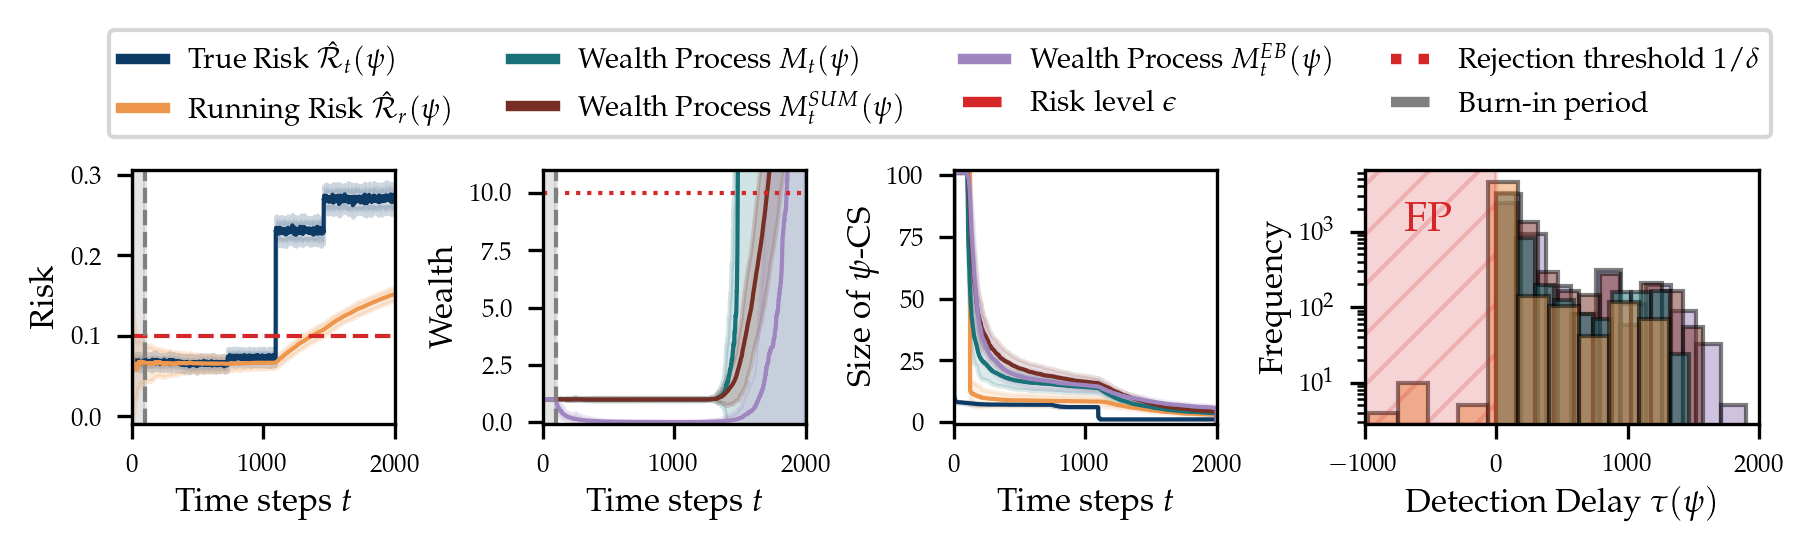

In [375]:
fig, axes = plt.subplots(1, 4, figsize=(7, 1.1), sharex=False, gridspec_kw={'wspace': 0.5, 'width_ratios': [1, 1, 1, 1.5]})

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel("Risk", labelpad=2)
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.01, max(point_risk_mean.max(), running_risk_mean.max()) + 0.03)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                eprocess_mean - eprocess_std, 
                eprocess_mean + eprocess_std, 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                naive_eprocess_mean - naive_eprocess_std, 
                naive_eprocess_mean + naive_eprocess_std, 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                pmeb_eprocess_mean - pmeb_eprocess_std, 
                pmeb_eprocess_mean + pmeb_eprocess_std, 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel("Wealth", labelpad=2)
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.1, (1 / cfg.EXP.DELTA) + 1)
ax.grid(False)

# Third subplot (Size of Psi-CS)
ax = axes[2]

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0).numpy()
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0).numpy()
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0).numpy()
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0).numpy()
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0).numpy()
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0).numpy()
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0).numpy()
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0).numpy()
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0).numpy()
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0).numpy()

ax.plot(point_risk_cs_size_mean, color=colors["point_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.15)
ax.plot(running_risk_cs_size_mean, color=colors["running_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.15)
ax.plot(eprocess_cs_size_mean, color=colors["eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.15)
ax.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.15)
ax.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.15)

ax.set_xlabel(r"Time steps $t$", labelpad=2)
ax.set_ylabel(r"Size of $\psi$-CS", labelpad=2)
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 1, len(psi_cand) + 1)
ax.grid(False)

# Fourth subplot (Detection delay + False alarm)
ax = axes[3]

# point_risk_detection_delay = point_risk.detection_delay.flatten().numpy()
running_risk_detection_delay = running_risk.detection_delay.flatten().numpy()
eprocess_detection_delay = eprocess.detection_delay.flatten().numpy()
naive_eprocess_detection_delay = naive_eprocess.detection_delay.flatten().numpy()
pmeb_eprocess_detection_delay = pmeb_eprocess.detection_delay.flatten().numpy()

# point_risk_detection_delay_mean = point_risk_detection_delay.mean()
running_risk_detection_delay_mean = running_risk_detection_delay.mean()
eprocess_detection_delay_mean = eprocess_detection_delay.mean()
naive_eprocess_detection_delay_mean = naive_eprocess_detection_delay.mean()
pmeb_eprocess_detection_delay_mean = pmeb_eprocess_detection_delay.mean()

running_risk_false_alarms_frac = (running_risk.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
eprocess_false_alarms_frac = (eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
naive_eprocess_false_alarms_frac = (naive_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
pmeb_eprocess_false_alarms_frac = (pmeb_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100

# ax.hist(point_risk_detection_delay, bins=10, alpha=0.5, density=False,
#          facecolor=colors["point_risk"], edgecolor='black')
ax.hist(pmeb_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["pmeb_eprocess"], edgecolor='black')
ax.hist(naive_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["naive_eprocess"], edgecolor='black')
ax.hist(eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["eprocess"], edgecolor='black')
ax.hist(running_risk_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["running_risk"], edgecolor='black')

ax.set_xlabel(r"Detection Delay $\tau(\psi)$", labelpad=2)
ax.set_ylabel("Frequency", labelpad=2)
ax.set_yscale('log')

# TODO: ADJUST HERE
ax.text(-700, 1000, 'FP', fontsize=10, fontweight="bold", color='tab:red') 
ax.set_xlim(-1000, 2000)
# ax.set_ylim(0, 1000)

xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, 0, color='tab:red', alpha=0.2, hatch='//')
ax.grid(False)

# Custom legend arrangement
lw = 2.5
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["point_risk"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=lw),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle='--', linewidth=lw),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle=':', linewidth=lw),
    Line2D([0, 1], [0, 1], color="grey", linestyle='--', linewidth=lw),
                  ]
legend_labels = [
    fr"True Risk $\hat{{\mathcal{{R}}}}_t$",
    fr"Running Risk $\hat{{\mathcal{{R}}}}_r$ ($\bar{{\tau}}$={running_risk_detection_delay_mean:.0f}, {running_risk_false_alarms_frac:.0f}\% $>\delta$))",
    fr"Wealth Process $M_t$ ($\bar{{\tau}}$={eprocess_detection_delay_mean:.0f}, {eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"Wealth Process $M^{{SUM}}_t$ ($\bar{{\tau}}$={naive_eprocess_detection_delay_mean:.0f}, {naive_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"Wealth Process $M^{{EB}}_t$ ($\bar{{\tau}}$={pmeb_eprocess_detection_delay_mean:.0f}, {pmeb_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]
legend_labels = [
    fr"True Risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running Risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

fig.legend(legend_handles, legend_labels, 
           loc='upper center', bbox_to_anchor=(0.51, 1.35), ncol=4,
           handlelength=1.5, handleheight=0.5, fontsize=7)

plt.tight_layout()

# save_fig(fig_dir, f"{fig_name_prefix}_combined")


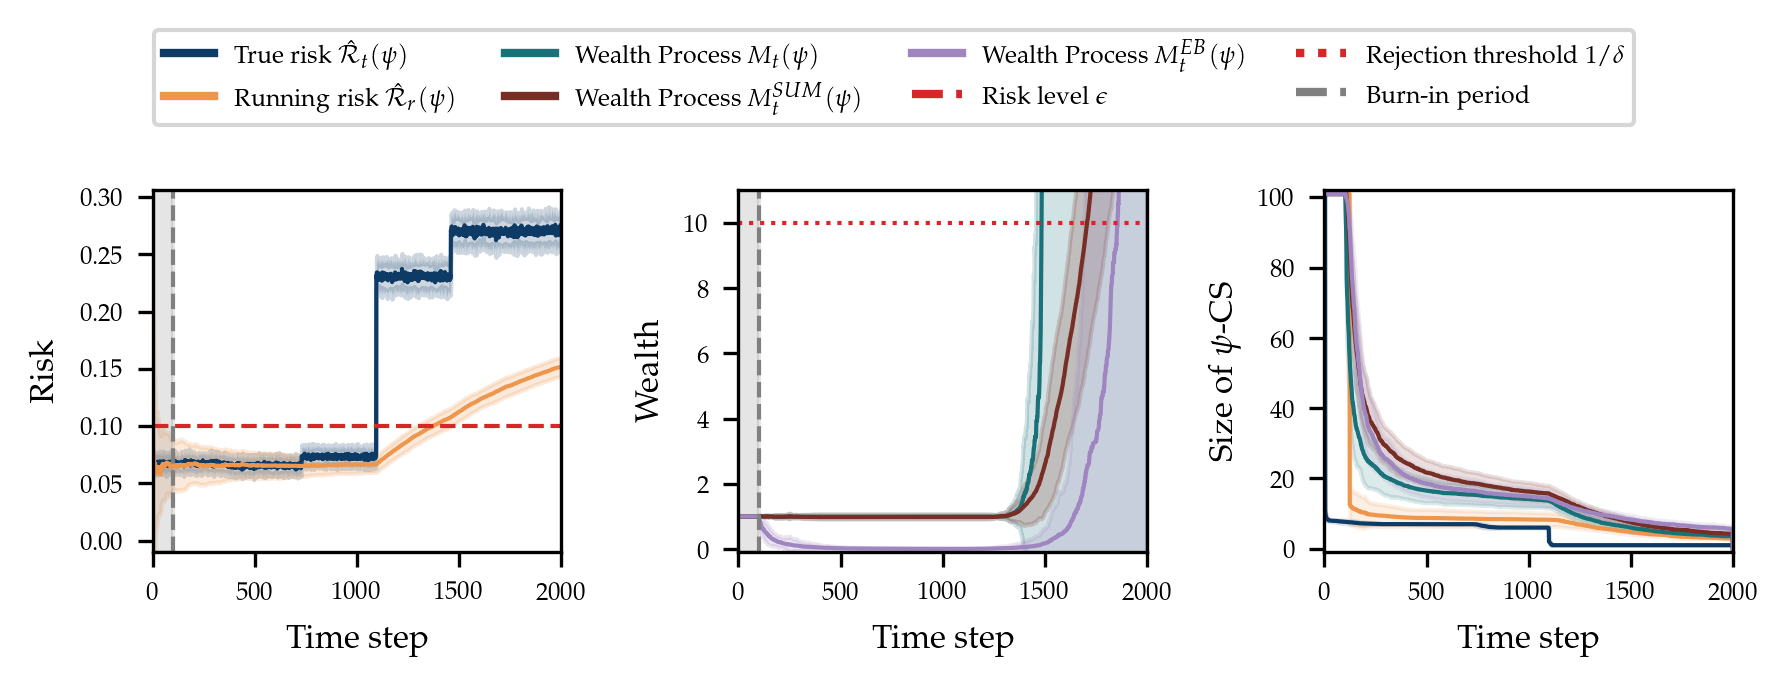

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(6, 1.8), sharex=True)

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Risk")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.01, max(point_risk_mean.max(), running_risk_mean.max()) + 0.03)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                eprocess_mean - eprocess_std, 
                eprocess_mean + eprocess_std, 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                naive_eprocess_mean - naive_eprocess_std, 
                naive_eprocess_mean + naive_eprocess_std, 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                pmeb_eprocess_mean - pmeb_eprocess_std, 
                pmeb_eprocess_mean + pmeb_eprocess_std, 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Wealth")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.1, (1 / cfg.EXP.DELTA) + 1)
ax.grid(False)

# Third subplot (Size of Psi-CS)
ax = axes[2]

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0).numpy()
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0).numpy()
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0).numpy()
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0).numpy()
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0).numpy()
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0).numpy()
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0).numpy()
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0).numpy()
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0).numpy()
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0).numpy()

ax.plot(point_risk_cs_size_mean, color=colors["point_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.15)
ax.plot(running_risk_cs_size_mean, color=colors["running_risk"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.15)
ax.plot(eprocess_cs_size_mean, color=colors["eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.15)
ax.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.15)
ax.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.15)

ax.set_xlabel("Time step")
ax.set_ylabel(r"Size of $\psi$-CS")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 1, len(psi_cand) + 1)
ax.grid(False)

# Custom legend arrangement
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["point_risk"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=2),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle='--', linewidth=2),
    Line2D([0, 1], [0, 1], color="tab:red", linestyle=':', linewidth=2),
    Line2D([0, 1], [0, 1], color="grey", linestyle='--', linewidth=2),
                  ]
legend_labels = [
    fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$",
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

fig.legend(legend_handles, legend_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4,
           handlelength=2, handleheight=1)
plt.tight_layout()

# save_fig(fig_dir, f"{fig_name_prefix}_combined")


## Other plots

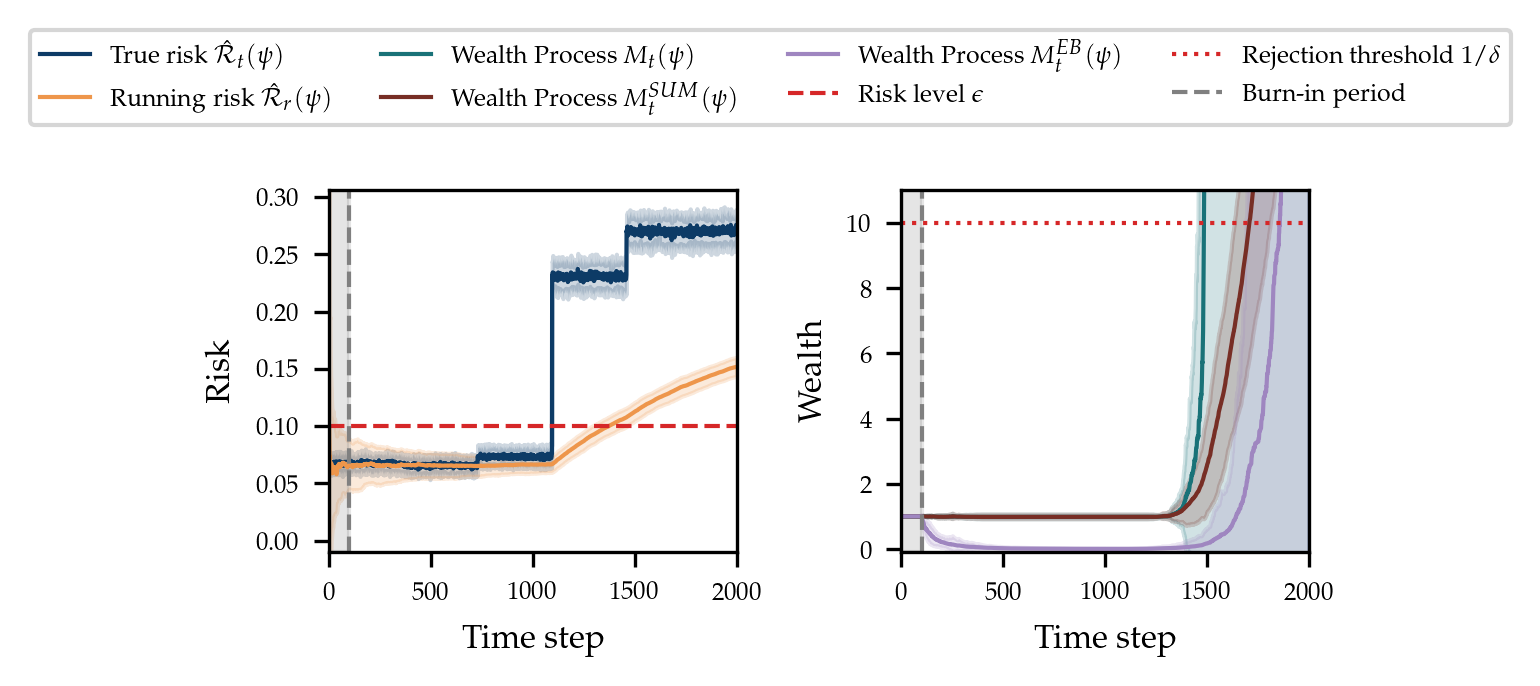

In [153]:

fig, axes = plt.subplots(1, 2, figsize=(4, 1.8), sharex=True)

# First subplot (Risk)
ax = axes[0]
point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

h1 = ax.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                point_risk_mean - point_risk_std, 
                point_risk_mean + point_risk_std, 
                color=colors["point_risk"], alpha=0.2)
h2 = ax.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                running_risk_mean - running_risk_std, 
                running_risk_mean + running_risk_std, 
                color=colors["running_risk"], alpha=0.2)

h3 = ax.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
h4 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Risk")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.01, max(point_risk_mean.max(), running_risk_mean.max()) + 0.03)
ax.grid(False)

# Second subplot (Wealth)
ax = axes[1]
eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

h5 = ax.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                eprocess_mean - eprocess_std, 
                eprocess_mean + eprocess_std, 
                color=colors["eprocess"], alpha=0.2)
h6 = ax.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                naive_eprocess_mean - naive_eprocess_std, 
                naive_eprocess_mean + naive_eprocess_std, 
                color=colors["naive_eprocess"], alpha=0.2)
h7 = ax.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])[0]
ax.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                pmeb_eprocess_mean - pmeb_eprocess_std, 
                pmeb_eprocess_mean + pmeb_eprocess_std, 
                color=colors["pmeb_eprocess"], alpha=0.2)

h8 = ax.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
h9 = ax.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
ax.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

ax.set_xlabel("Time step")
ax.set_ylabel("Wealth")
ax.set_xlim(0, cfg.EXP.NR_TIMESTEPS)
ax.set_ylim(0 - 0.1, (1 / cfg.EXP.DELTA) + 1)
ax.grid(False)

# Custom legend arrangement
first_row_handles = [h1, h2, h5, h6, h7]  # Methods
first_row_labels = [
    fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$",
    fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$",
    fr"Wealth Process $M_t(\psi)$",
    fr"Wealth Process $M^{{SUM}}_t(\psi)$",
    fr"Wealth Process $M^{{EB}}_t(\psi)$"
]

second_row_handles = [h3, h8, h4]  # Other elements
second_row_labels = [
    rf"Risk level $\epsilon$",
    rf"Rejection threshold $1/\delta$",
    "Burn-in period",
]

# Create a joint legend with two rows
fig.legend(first_row_handles + second_row_handles, first_row_labels + second_row_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4)

plt.tight_layout()
# save_fig(fig_dir, f"{fig_name_prefix}_combined")

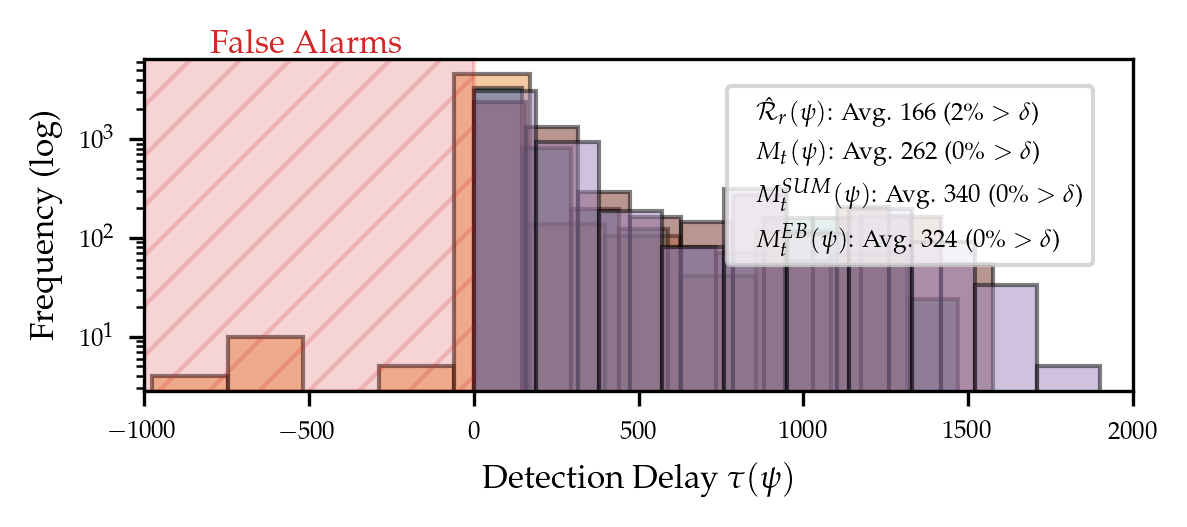

In [311]:
fig, ax = plt.subplots(figsize=(4, 1.8))

# point_risk_detection_delay = point_risk.detection_delay.flatten().numpy()
running_risk_detection_delay = running_risk.detection_delay.flatten().numpy()
eprocess_detection_delay = eprocess.detection_delay.flatten().numpy()
naive_eprocess_detection_delay = naive_eprocess.detection_delay.flatten().numpy()
pmeb_eprocess_detection_delay = pmeb_eprocess.detection_delay.flatten().numpy()

# point_risk_detection_delay_mean = point_risk_detection_delay.mean()
running_risk_detection_delay_mean = running_risk_detection_delay.mean()
eprocess_detection_delay_mean = eprocess_detection_delay.mean()
naive_eprocess_detection_delay_mean = naive_eprocess_detection_delay.mean()
pmeb_eprocess_detection_delay_mean = pmeb_eprocess_detection_delay.mean()

running_risk_false_alarms_frac = (running_risk.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
eprocess_false_alarms_frac = (eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
naive_eprocess_false_alarms_frac = (naive_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100
pmeb_eprocess_false_alarms_frac = (pmeb_eprocess.false_alarms.mean(dim=0).numpy() > cfg.EXP.DELTA).mean() * 100

# ax.hist(point_risk_detection_delay, bins=10, alpha=0.5, density=False,
#          facecolor=colors["point_risk"], edgecolor='black')
ax.hist(running_risk_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["running_risk"], edgecolor='black')
ax.hist(eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["eprocess"], edgecolor='black')
ax.hist(naive_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["naive_eprocess"], edgecolor='black')
ax.hist(pmeb_eprocess_detection_delay, bins=10, alpha=0.5, density=False,
         facecolor=colors["pmeb_eprocess"], edgecolor='black')

ax.text(-800, 7500, 'False Alarms', fontsize=8, color='tab:red')
ax.set_xlabel(r"Detection Delay $\tau(\psi)$")
ax.set_ylabel("Frequency")
ax.set_yscale('log')
ax.set_xlim(-1000, 2000)
# ax.set_ylim(0, 1000)
xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, 0, color='tab:red', alpha=0.2, hatch='//')
ax.grid(False)

# Custom legend arrangement
legend_handles = [
    Line2D([0, 1], [0, 1], color=colors["running_risk"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["eprocess"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["naive_eprocess"], linewidth=1),
    Line2D([0, 1], [0, 1], color=colors["pmeb_eprocess"], linewidth=1),
                  ]
legend_labels = [
    fr"$\hat{{\mathcal{{R}}}}_r(\psi)$: Avg. {running_risk_detection_delay_mean:.0f} ({running_risk_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M_t(\psi)$: Avg. {eprocess_detection_delay_mean:.0f} ({eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M^{{SUM}}_t(\psi)$: Avg. {naive_eprocess_detection_delay_mean:.0f} ({naive_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
    fr"$M^{{EB}}_t(\psi)$: Avg. {pmeb_eprocess_detection_delay_mean:.0f} ({pmeb_eprocess_false_alarms_frac:.0f}\% $>\delta$)",
]

fig.legend(legend_handles, legend_labels, 
           bbox_to_anchor=(0.6, 0.85),
           loc='upper left', handlelength=0)
fig.tight_layout()


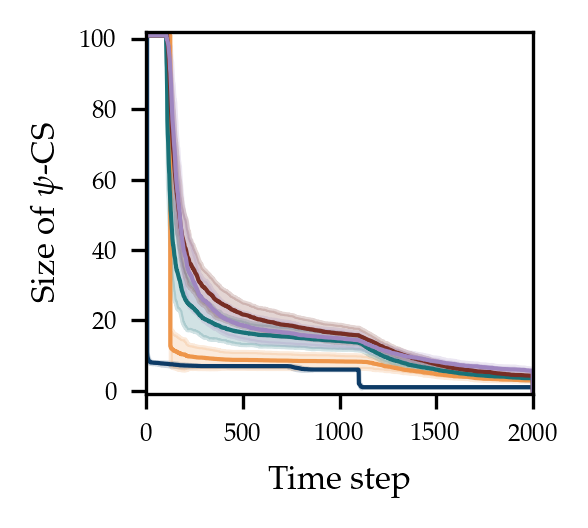

In [154]:
plt.figure(figsize=(2, 1.8))

point_risk_cs_size_mean = point_risk.psi_cs_size.mean(dim=0)
point_risk_cs_size_std = point_risk.psi_cs_size.std(dim=0)
running_risk_cs_size_mean = running_risk.psi_cs_size.mean(dim=0)
running_risk_cs_size_std = running_risk.psi_cs_size.std(dim=0)
eprocess_cs_size_mean = eprocess.psi_cs_size.mean(dim=0)
eprocess_cs_size_std = eprocess.psi_cs_size.std(dim=0)
naive_eprocess_cs_size_mean = naive_eprocess.psi_cs_size.mean(dim=0)
naive_eprocess_cs_size_std = naive_eprocess.psi_cs_size.std(dim=0)
pmeb_eprocess_cs_size_mean = pmeb_eprocess.psi_cs_size.mean(dim=0)
pmeb_eprocess_cs_size_std = pmeb_eprocess.psi_cs_size.std(dim=0)

plt.plot(point_risk_cs_size_mean, color=colors["point_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 point_risk_cs_size_mean - point_risk_cs_size_std, 
                 point_risk_cs_size_mean + point_risk_cs_size_std, 
                 color=colors["point_risk"], alpha=0.2)
plt.plot(running_risk_cs_size_mean, color=colors["running_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 running_risk_cs_size_mean - running_risk_cs_size_std, 
                 running_risk_cs_size_mean + running_risk_cs_size_std, 
                 color=colors["running_risk"], alpha=0.2)
plt.plot(eprocess_cs_size_mean, color=colors["eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 eprocess_cs_size_mean - eprocess_cs_size_std, 
                 eprocess_cs_size_mean + eprocess_cs_size_std, 
                 color=colors["eprocess"], alpha=0.2)
plt.plot(naive_eprocess_cs_size_mean, color=colors["naive_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 naive_eprocess_cs_size_mean - naive_eprocess_cs_size_std, 
                 naive_eprocess_cs_size_mean + naive_eprocess_cs_size_std, 
                 color=colors["naive_eprocess"], alpha=0.2)
plt.plot(pmeb_eprocess_cs_size_mean, color=colors["pmeb_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                 pmeb_eprocess_cs_size_mean - pmeb_eprocess_cs_size_std, 
                 pmeb_eprocess_cs_size_mean + pmeb_eprocess_cs_size_std, 
                 color=colors["pmeb_eprocess"], alpha=0.2)

plt.xlabel("Time step")
plt.ylabel(r"Size of $\psi$-CS")
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 1, len(psi_cand) + 1)
plt.grid(False)

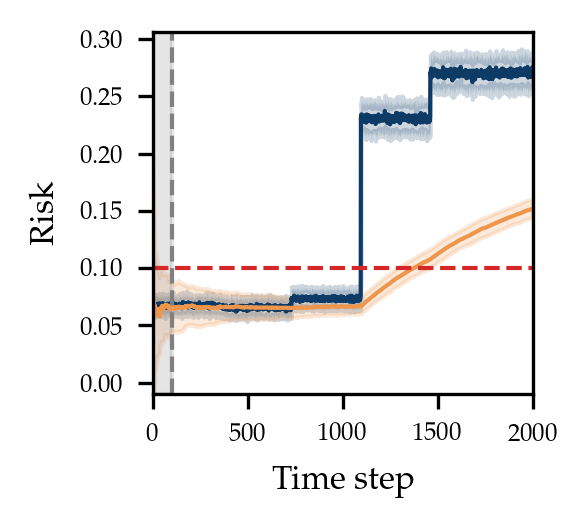

In [156]:
plt.figure(figsize=(2, 1.8))

point_risk_mean = point_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
point_risk_std = point_risk.risk[:, :, psi_idx].std(dim=0).numpy()
running_risk_mean = running_risk.risk[:, :, psi_idx].mean(dim=0).numpy()
running_risk_std = running_risk.risk[:, :, psi_idx].std(dim=0).numpy()

plt.plot(point_risk_mean, label=fr"True risk $\hat{{\mathcal{{R}}}}_t(\psi)$", color=colors["point_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    point_risk_mean - point_risk_std, 
                    point_risk_mean + point_risk_std,
                    color=colors["point_risk"],
                    alpha=0.2)
plt.plot(running_risk_mean, label=fr"Running risk $\hat{{\mathcal{{R}}}}_r(\psi)$", color=colors["running_risk"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    running_risk_mean - running_risk_std, 
                    running_risk_mean + running_risk_std, 
                    color=colors["running_risk"],
                    alpha=0.2)

plt.axhline(cfg.EXP.EPS, color='tab:red', linestyle='--', label=rf"Risk level $\epsilon$")
plt.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
plt.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

# eps_upper = 1.0
eps_upper = max(point_risk_mean.max(), running_risk_mean.max())

plt.xlabel("Time step")
plt.ylabel("Risk")
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 0.01, eps_upper + 0.03)
plt.grid(False)

# save_fig(fig_dir, f"{fig_name_ prefix}_risk")

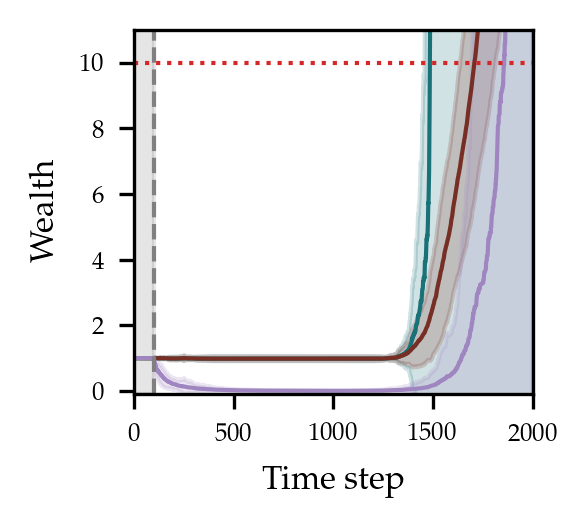

In [155]:
plt.figure(figsize=(2, 1.8))

eprocess_mean = eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
eprocess_std = eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
naive_eprocess_mean = naive_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
naive_eprocess_std = naive_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()
pmeb_eprocess_mean = pmeb_eprocess.eprocess[:, :, psi_idx].mean(dim=0).numpy()
pmeb_eprocess_std = pmeb_eprocess.eprocess[:, :, psi_idx].std(dim=0).numpy()

plt.plot(eprocess_mean, label=fr"Wealth Process $M_t(\psi)$", color=colors["eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    eprocess_mean - eprocess_std, 
                    eprocess_mean + eprocess_std, 
                    color=colors["eprocess"],
                    alpha=0.2)
plt.plot(naive_eprocess_mean, label=fr"Wealth Process $M^{{SUM}}_t(\psi)$", color=colors["naive_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    naive_eprocess_mean - naive_eprocess_std, 
                    naive_eprocess_mean + naive_eprocess_std,
                    color=colors["naive_eprocess"],
                    alpha=0.2)
plt.plot(pmeb_eprocess_mean, label=fr"Wealth Process $M^{{EB}}_t(\psi)$", color=colors["pmeb_eprocess"])
plt.fill_between(range(cfg.EXP.NR_TIMESTEPS), 
                    pmeb_eprocess_mean - pmeb_eprocess_std, 
                    pmeb_eprocess_mean + pmeb_eprocess_std,
                    color=colors["pmeb_eprocess"], 
                    alpha=0.2)

plt.axhline(1 / cfg.EXP.DELTA, color='tab:red', linestyle=':', label=rf"Rejection threshold $1/\delta$")
plt.axvline(cfg.EXP.NR_BURNIN, color='grey', linestyle='--', label="Burn-in period")
plt.axvspan(0, cfg.EXP.NR_BURNIN, color='grey', alpha=0.2)

wealth_upper = (1 / cfg.EXP.DELTA)

plt.xlabel("Time step")
plt.ylabel("Wealth")
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=5)
plt.xlim(0, cfg.EXP.NR_TIMESTEPS)
plt.ylim(0 - 0.1, wealth_upper + 1)
plt.grid(False)

# save_fig(fig_dir, f"{fig_name_prefix}_wealth")